In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats 
import os
from math import exp,log
from dotenv import load_dotenv

load_dotenv()
data_path = str(os.getenv("Data_path"))

df = pd.read_csv(data_path)

print(df.columns)


Index(['patient_id', 'age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl',
       'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'smoking',
       'alcohol_consumption', 'physical_activity', 'family_history',
       'disease'],
      dtype='str')


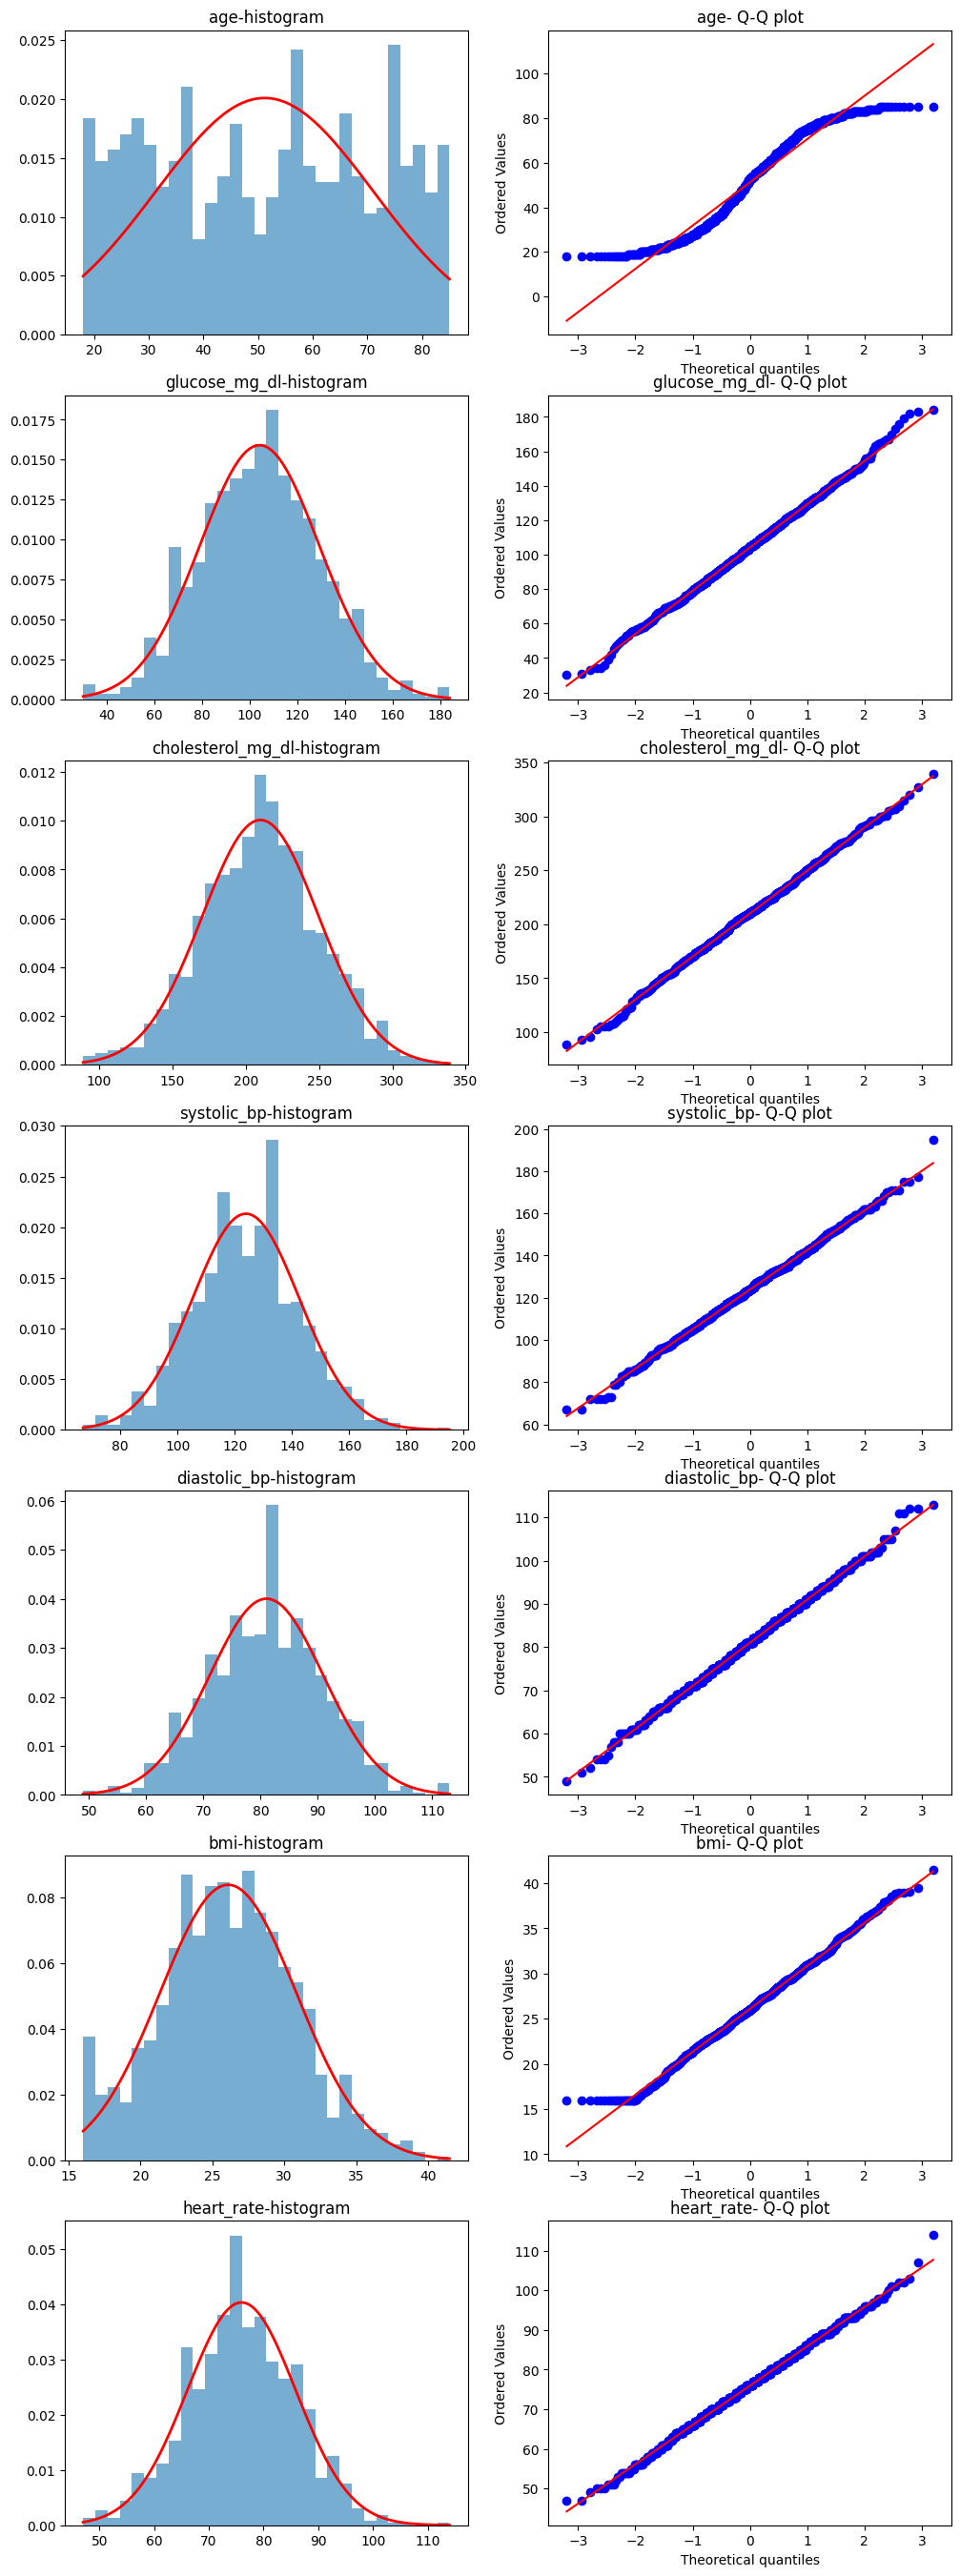

In [2]:
continuous =['age','glucose_mg_dl','cholesterol_mg_dl',
       'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate']

fig, axes = plt.subplots(len(continuous),2,figsize=(12,4*len(continuous)+6))

for i,col in enumerate(continuous):
    data = df[col].dropna()
    axes[i,0].hist(data,bins=30,density = True,alpha =0.6)
    mu,std = data.mean(),data.std()
    x = np.linspace(data.min(),data.max(),100)
    axes[i,0].plot(x,stats.norm.pdf(x,mu,std),'r-',linewidth=2)
    axes[i,0].set_title(f"{col}-histogram")

    stats.probplot(data,dist='norm',plot=axes[i,1])
    axes[i,1].set_title(f"{col}- Q-Q plot")
 

<Axes: >

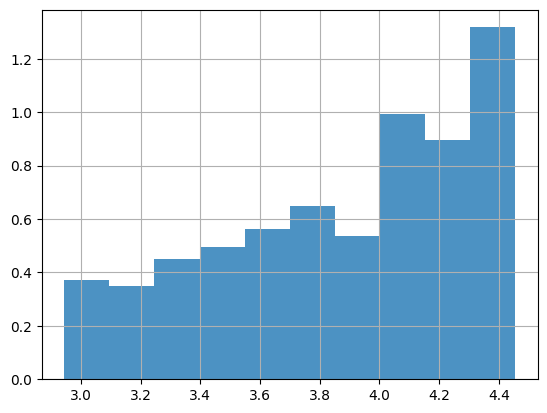

In [3]:
fig2 , ax2 = plt.subplots()
df['age'] = np.log1p(df['age'])
df['age'].hist(ax=ax2,bins=10,density=True,alpha=0.8)


In [4]:
# mapping

df['gender'] = df['gender'].map({'Male':1,'Female':0})
df['smoking'] = df['smoking'].map({'Yes':1,'No':0})
df['alcohol_consumption'] = df['alcohol_consumption'].map({'Yes':1,'No':0})
df['disease'] = df['disease'].map({'Yes':1,'No':0})
df = pd.get_dummies(df,columns=['physical_activity'],drop_first=True,dtype=int)
df['family_history'] = df['family_history'].map({'Yes':1,'No':0})


In [5]:
#spliting features and outcome
y= df['disease'].values

df.drop(columns=['disease','patient_id'],inplace=True)

x= df.values


In [6]:
#splitting sets

np.random.seed(69)

idx = np.random.permutation(len(x))
split = int(0.8*len(x))

x_train,x_test = x[idx[:split]],x[idx[split:]]
y_train,y_test = y[idx[:split]],y[idx[split:]]


In [7]:
#splitting into classes

x0 = x_train[y_train==0]
x1 = x_train[y_train==1]

print(f"sick {len(x1)} pat")

sick 399 pat


In [8]:
#prior probability

phi_y1 = len(x1)/len(x_train)
phi_y0 = len(x0)/len(x_train)

print(f"P(sick):{phi_y1:.2f}")

P(sick):0.50


In [9]:
#gaussain parameters
gaussian_col = [0,2,3,4,5,6]

mu_0 = x0[:,gaussian_col].mean(axis=0)
mu_1 = x1[:,gaussian_col].mean(axis=0)

std_0 = x0[:,gaussian_col].std(axis=0)
std_1 = x1[:,gaussian_col].std(axis=0)

print(f"mean(no disease):",mu_0.round(2))


mean(no disease): [  3.77  97.98 203.6  120.44  81.12  25.25]


In [10]:
#bernoulli parameters

bernoulli_col = [1,8,9,10,11,12]

phi_0 = x0[:,bernoulli_col].mean(axis=0)
phi_1 = x1[:,bernoulli_col].mean(axis=0)


In [11]:
#gussian pdf

def guassian_pdf(x,mu,sigma):
    coff = 1/(sigma*np.sqrt(2*np.pi))

    expo = -((x-mu)**2/(2*sigma**2))

    return coff*np.exp(expo)

print(f" at mean {guassian_pdf(mu_0,mu_0,std_0)}")
print(f" at  {guassian_pdf(mu_0+std_0*10,mu_0,std_0)}")

 at mean [0.94853925 0.01828746 0.0109309  0.0241198  0.03980327 0.09231864]
 at  [1.82949494e-22 3.52719347e-24 2.10829805e-24 4.65210641e-24
 7.67705418e-24 1.78059571e-23]


In [12]:
#log liklihood
def log_liklihood(x,mu,sigma,phi_bern,phi_y):
    gauss_x = x[gaussian_col]
    gauss_ll = np.sum(np.log(guassian_pdf(gauss_x,mu,sigma)+1e-9))

    bern_x = x[bernoulli_col]
    bern_ll = np.sum(bern_x*np.log(phi_bern+1e-9)+(1-bern_x)*((1-phi_bern)+1e-9))

    prior = np.log(phi_y)

    return prior+bern_ll+gauss_ll

In [13]:
#prediction for each patients

def predict(x_test):
    prediction = []
    for x in x_test:
        ll_0 = log_liklihood(x,mu_0,std_0,phi_0,phi_y0)
        ll_1 = log_liklihood(x,mu_1,std_1,phi_1,phi_y1)

        prediction.append(1 if ll_1>ll_0 else 0)

    return np.array(prediction)

y_pred = predict(x_test)
print(y_pred)

[0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0 1 0 0 1
 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 0 0 0
 1 0 1 0 1 0 0 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1
 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0 1
 1 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 0
 0 1 1 1 0 1 1 0 0 1 1 1 0 1 1]


In [14]:
acu = np.mean(y_pred==y_test)

TP = np.sum((y_pred==1)&(y_test==1))
TN = np.sum((y_pred==0)&(y_test==0))
FP = np.sum((y_pred==1)&(y_test==0))
FN = np.sum((y_pred==0)&(y_test==1))

recall = TP/(TP+FN)
precision = TP/(TP+FP)

print(f"recall-{recall:.2f} && acu-{acu:.2f}")
print(f"TP : {TP} TN: {TN} FP:{FP} FN: {FN}")

recall-0.96 && acu-0.85
TP : 98 TN: 72 FP:26 FN: 4


Text(0.5, 1.0, 'Confusion Matric')

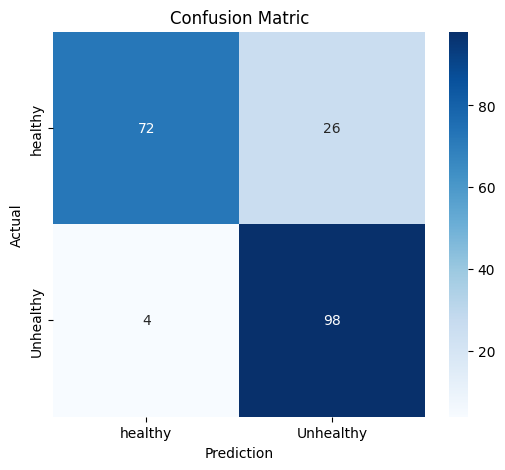

In [15]:
cm = np.array([[TN,FP],[FN,TP]])

fig3,ax3 = plt.subplots(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['healthy','Unhealthy'],
            yticklabels=['healthy','Unhealthy'],
            ax=ax3)
ax3.set_xlabel("Prediction")
ax3.set_ylabel("Actual")
ax3.set_title("Confusion Matric")